# BreaKHis Model Development

With the split fixed, this is the notebook where the image model actually gets trained and compared. I already have a saved checkpoint from the full corrected patient-level run, so I am loading that back in here rather than rerunning a long training loop every time I open the notebook. The first cheap thing I tried was a frozen ImageNet feature extractor, and I have kept that result alongside the full fine-tune because the comparison tells an important part of the story.


## Notebook Purpose

This notebook documents the image-model development stage. It records the corrected patient-level split sizes, the checkpoint paths, and the saved training/development outputs used to select the final BreaKHis model.


## Why This Matters

The final image checkpoint should not appear as an unexplained artifact. This notebook connects the selected model to its development evidence: training history, validation behaviour, and comparison outputs.


## Resolve Training Inputs And Artifacts

This setup cell loads the full corrected split and defines the checkpoint paths. It makes clear which model file is the older baseline and which one is the clean patient-level checkpoint intended for final inference.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

import torch
from IPython.display import display

from src.breakhis import build_binary_records, patient_level_split
from src.fusion import aggregate_image_embeddings, extract_image_embeddings, run_patient_level_image_baseline
from src.image_pipeline import save_history_plot, train_breakhis_baseline

df = build_binary_records(DATA_ROOT)
split = patient_level_split(df, random_state=SEED)
train_full = split.train.reset_index(drop=True)
val_full = split.val.reset_index(drop=True)
test_full = split.test.reset_index(drop=True)
frozen_features_checkpoint = MODELS / 'breakhis_resnet18_baseline.pth'
clean_checkpoint = MODELS / 'breakhis_resnet18_patient_level_clean.pth'
print('Full corrected split sizes:', {'train': len(train_full), 'val': len(val_full), 'test': len(test_full)})


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs


Full corrected split sizes: {'train': 5403, 'val': 1171, 'test': 1335}


## How the training run was set up

The clean run used 5,403 training images, 1,171 for validation, and 1,335 for test, all from the corrected patient-level split. Normalisation came from BreaKHis itself rather than being copied over directly from ImageNet, and the augmentations stayed fairly light. Histology texture does not really survive aggressive augmentation without starting to look like something else.

I stopped once the validation accuracy had clearly flattened and the later epochs were drifting the wrong way. That is still a judgement call, but it felt more sensible than fixing an arbitrary epoch count in advance and pretending it had special meaning. The saved checkpoint is the best-validation one, not the final epoch.


## Load Training History And Development Comparison

This cell reads the saved training metrics rather than retraining. The tables provide the evidence used to discuss model behaviour, including whether validation performance supports the selected checkpoint.


In [2]:
history_df = pd.read_csv(METRICS / 'breakhis_patient_history.csv')
comparison_df = pd.read_csv(METRICS / 'breakhis_model_development_runs.csv')
display(history_df)
display(comparison_df)


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.3437,0.8538,0.5509,0.8668
1,2,0.2904,0.8780,0.4119,0.8565
2,3,0.2618,0.8852,0.5719,0.8070


,run_name,accuracy,precision,recall,f1_score,roc_auc,brier_score,ece,best_val_accuracy
0,initial_frozen_features_full_split,0.923077,1.000,0.888889,0.941176,1.000000,0.047740,NaN,NaN
1,clean_breakhis_augmented_full_split,0.769231,0.875,0.777778,0.823529,0.888889,0.149788,0.234854,0.8668


## Display Development Figures

This cell surfaces the saved training curve and model-development comparison figure. These are communication artifacts for the dissertation rather than new computation.


Training curve


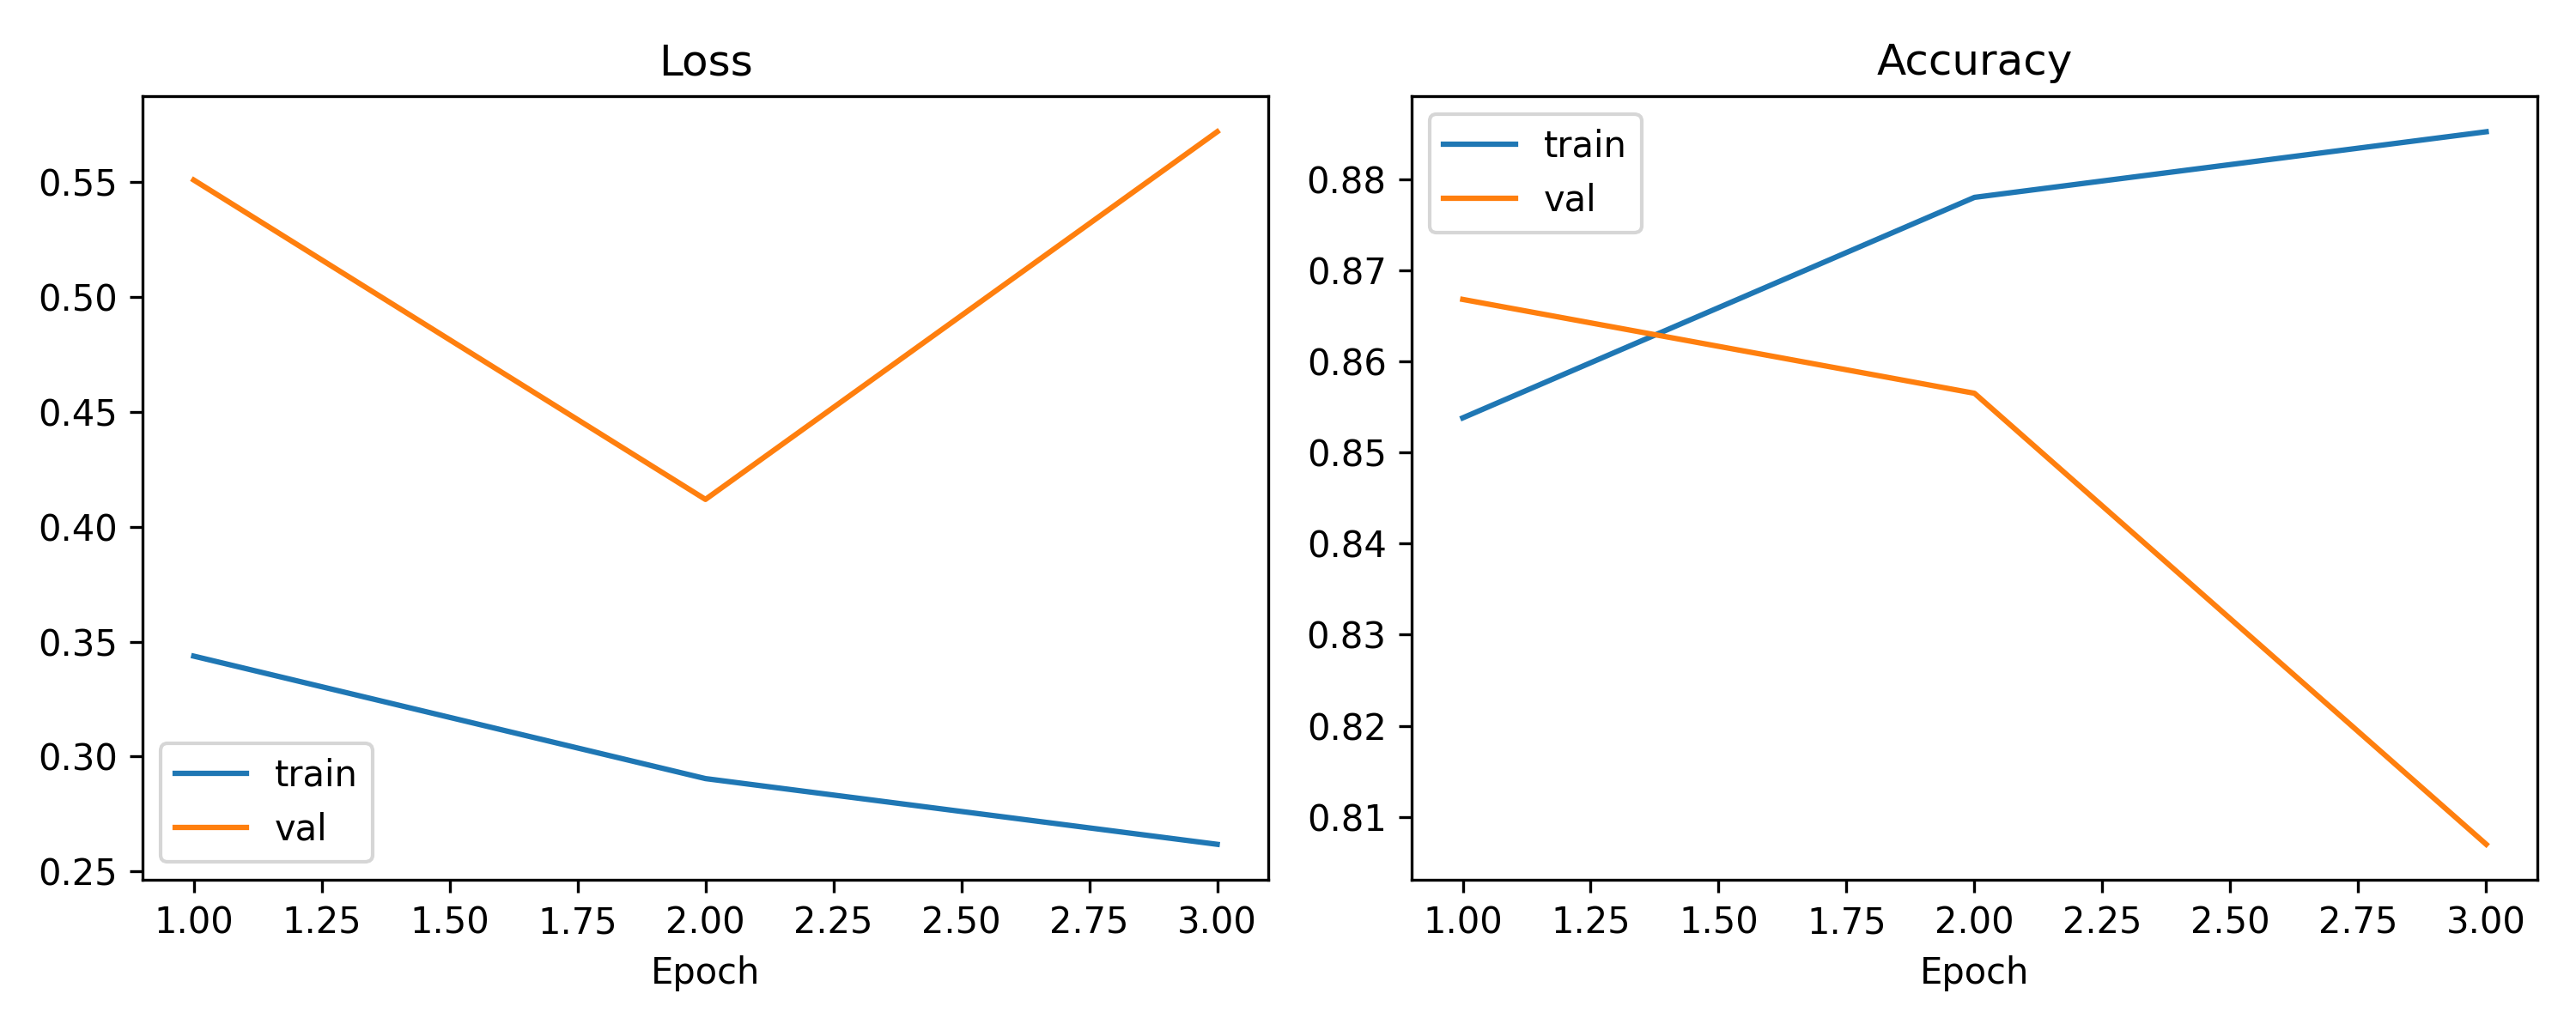

Development comparison figure


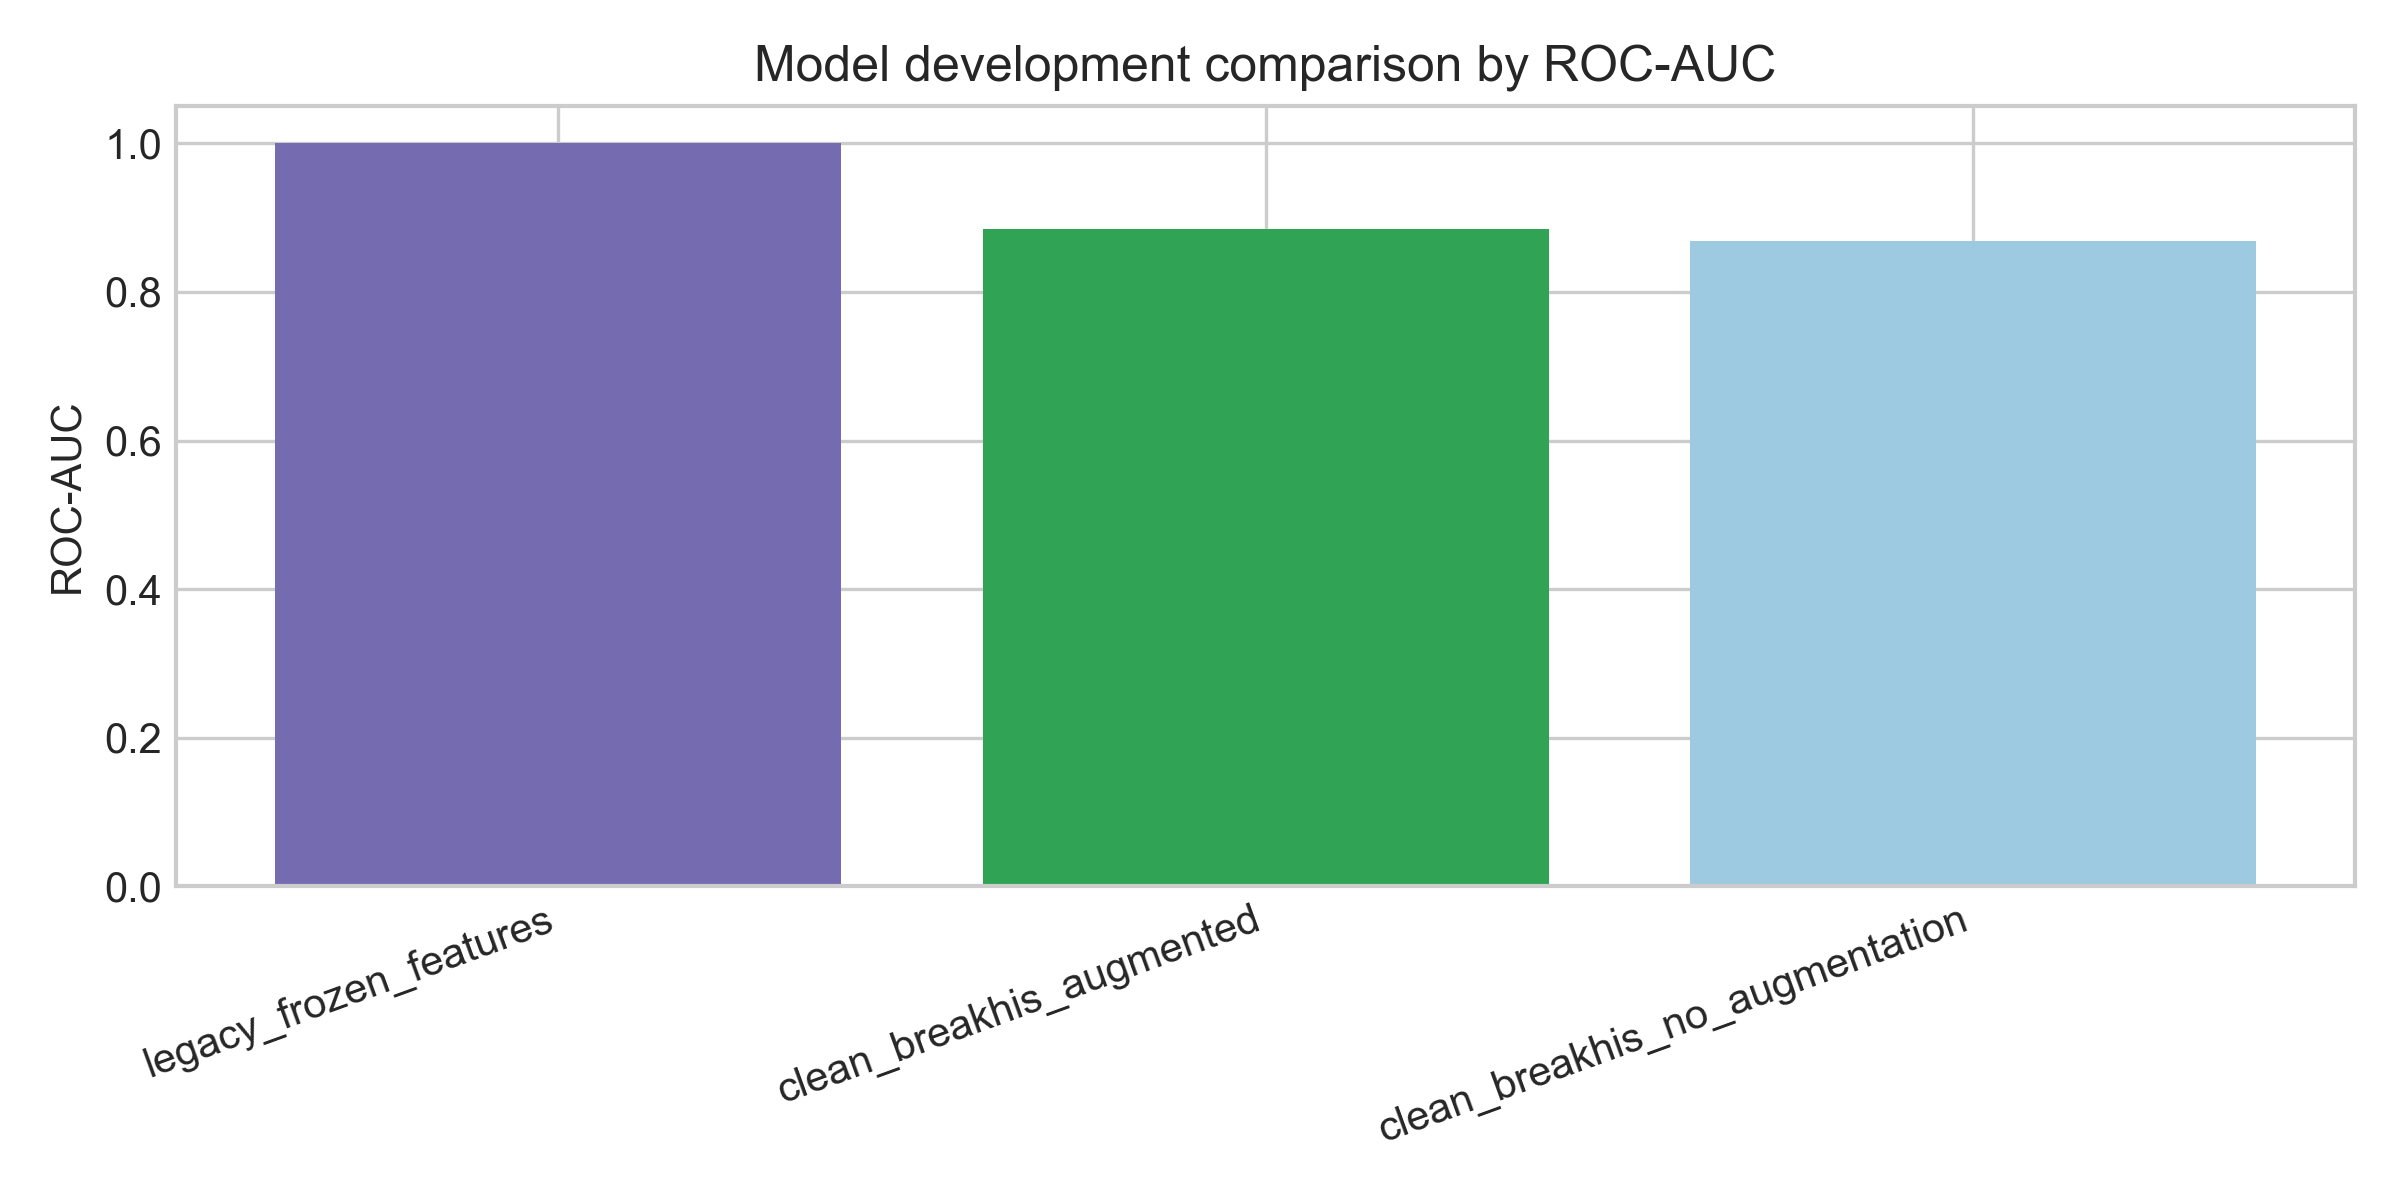

In [3]:
from IPython.display import Image, display

print('Training curve')
display(Image(filename=str(FIGURES / 'breakhis_patient_history.png')))
print('Development comparison figure')
display(Image(filename=str(FIGURES / 'breakhis_model_development_comparison.png')))


## What this run actually shows

Two things matter here. First, this is the point where the clean model really does train end to end on the full corrected split rather than on the smaller development subsets I used while iterating. Second, the frozen-feature comparator still scores higher on paper, which was frustrating but important to keep visible. I still treat the clean fine-tuned model as the main image branch because it matches the corrected split and full training setup I actually want to stand behind. The frozen-feature result stays in the notebook as the first cheap attempt, with that caveat attached wherever it appears.


## How This Notebook Supports The Dissertation

This notebook explains why the final image checkpoint is the one transferred into the web app. It keeps model selection tied to saved evidence instead of treating the checkpoint as a black box.
